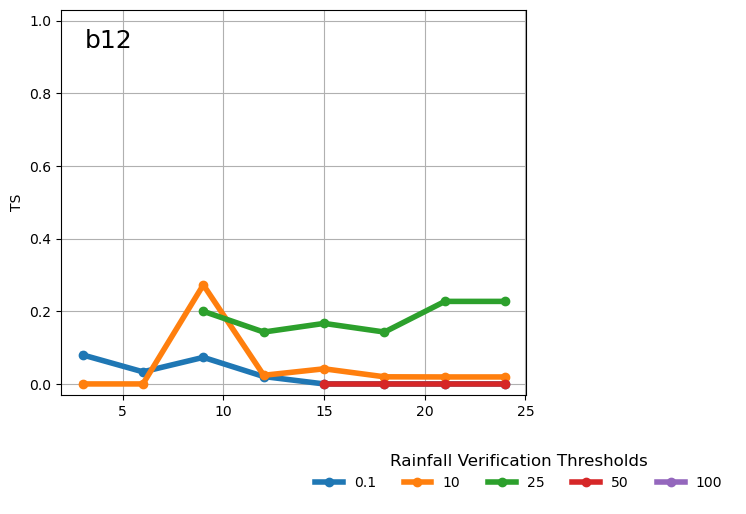

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from matplotlib.font_manager import FontProperties


# 定义上传的 Excel 文件路径
file_path =  r"C:\Users\xmxm\Desktop\汇总制图\汇总NANBNC_b12.xlsx"


title = os.path.splitext(os.path.basename(file_path))[0].split('_')[-1]

# 读取 Excel 文件
data = pd.read_excel(file_path)

# 将系列数据提取为紧凑形式
series_list = [data.iloc[i, 11:19].tolist() for i in range(7, 12)]

# 定义 x 轴数值
x = [3, 6, 9, 12, 15, 18, 21, 24]

colors = [
    [255/255, 255/255, 255/255],   # 1: 白色
    [165/255, 221/255, 236/255],   # 2: 淡蓝色
    [113/255, 177/255, 226/255],   # 3: 中蓝色
    [133/255, 196/255, 63/255],    # 4: 淡绿色
    [110/255, 189/255, 68/255]     # 5: 中绿色
]

# 为了便于绘图，创建 DataFrame
plot_data = pd.DataFrame({
    'x': x,
    '0.1': series_list[0],
    '10': series_list[1],
    '25': series_list[2],
    '50': series_list[3],
    '100': series_list[4]
})

line_width = 4  # 您可以根据需要调整此值

# 绘制数据
plt.figure(figsize=(6, 5))
for column in plot_data.columns[1:]:
    plt.plot(plot_data['x'], plot_data[column], marker='o', label=column, linewidth=line_width)

#plt.xlabel('X 轴')
plt.ylabel('TS')
#plt.title('多线图')
#plt.title(title)  # 设置提取的标题

#纵坐标
plt.ylim(-0.03, 1.03)

# 图例
###纵向排列
#plt.legend(title='检验阈值', loc='upper left', fontsize='medium', title_fontsize='large', frameon=True, shadow=True, borderpad=1, ncol=1)
###横向排列
plt.legend(title='Rainfall Verification Thresholds', loc='upper left', bbox_to_anchor=(0.5, -0.1), fontsize='medium', title_fontsize='large', frameon=False, shadow=True, borderpad=1, ncol=5)

# 将标题放在网格内左上角
plt.text(0.05, 0.95, title, fontsize=18, ha='left', va='top', transform=plt.gca().transAxes)


plt.grid(True)
plt.show()


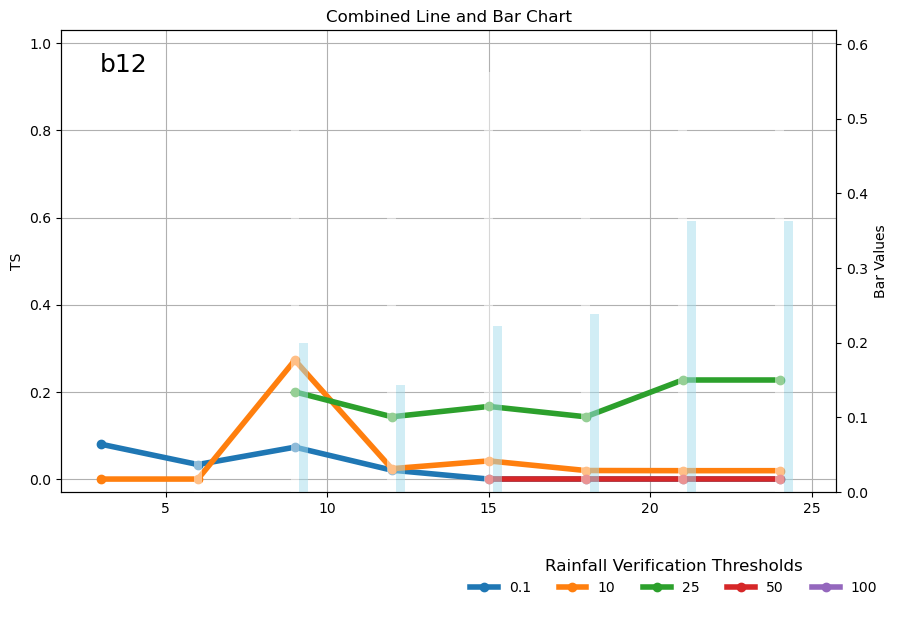

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from matplotlib.font_manager import FontProperties

# 定义上传的 Excel 文件路径
file_path =  r"C:\Users\xmxm\Desktop\汇总制图\汇总NANBNC_b12.xlsx"

title = os.path.splitext(os.path.basename(file_path))[0].split('_')[-1]

# 读取 Excel 文件
data = pd.read_excel(file_path)

# 将系列数据提取为紧凑形式
series_list = [data.iloc[i, 11:19].tolist() for i in range(7, 12)]

# 提取柱状图数据（假设数据在第15行开始）
bar_data = data.iloc[15:20, 11:19].values

# 定义 x 轴数值
x = [3, 6, 9, 12, 15, 18, 21, 24]

colors = [
    [255/255, 255/255, 255/255],   # 1: 白色
    [165/255, 221/255, 236/255],   # 2: 淡蓝色
    [113/255, 177/255, 226/255],   # 3: 中蓝色
    [133/255, 196/255, 63/255],    # 4: 淡绿色
    [110/255, 189/255, 68/255]     # 5: 中绿色
]

# 为了便于绘图，创建 DataFrame
plot_data = pd.DataFrame({
    'x': x,
    '0.1': series_list[0],
    '10': series_list[1],
    '25': series_list[2],
    '50': series_list[3],
    '100': series_list[4]
})

line_width = 4  # 您可以根据需要调整此值

# 绘制数据
fig, ax1 = plt.subplots(figsize=(10, 6))

# 绘制折线图
for column in plot_data.columns[1:]:
    ax1.plot(plot_data['x'], plot_data[column], marker='o', label=column, linewidth=line_width)

ax1.set_ylabel('TS')
ax1.set_ylim(-0.03, 1.03)
ax1.legend(title='Rainfall Verification Thresholds', loc='upper left', bbox_to_anchor=(0.5, -0.1), fontsize='medium', title_fontsize='large', frameon=False, shadow=True, borderpad=1, ncol=5)
ax1.grid(True)

# 添加柱状图
ax2 = ax1.twinx()  # 创建共享x轴的第二个y轴
bar_width = 0.8  # 柱状图宽度

for i, row in enumerate(bar_data):
    ax2.bar([xi + i * bar_width/len(bar_data) for xi in x], row, bar_width/len(bar_data), label=f'Bar {i+1}', color=colors[i % len(colors)], alpha=0.5)

ax2.set_ylabel('Bar Values')
ax2.set_ylim(0, max(bar_data.flatten()) * 1.1)  # 适当调整y轴范围

# 将标题放在网格内左上角
plt.text(0.05, 0.95, title, fontsize=18, ha='left', va='top', transform=plt.gca().transAxes)

plt.title('Combined Line and Bar Chart')

plt.show()


In [ ]:


###可用堆叠柱状



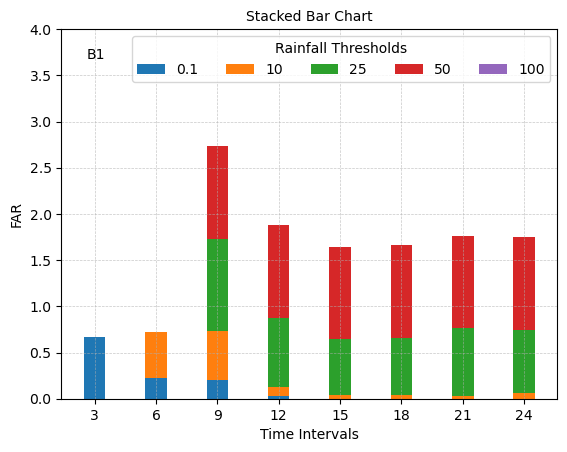

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# 读取Excel文件
file_path = "C:/Users/xmxm/Desktop/汇总制图/汇总NANBNC_b1.xlsx"
sheet_name = "Sheet1"
df = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

# 提取所需数据
data = df.iloc[8:13, 11:19].values

# 将"#DIV/0!"替换为NaN，并转换为浮点数
data[data == "#DIV/0!"] = np.nan
data = data.astype(float)

# 创建堆叠柱状图
rainfall_thresholds = [0.1, 10, 25, 50, 100]
time_intervals = [3, 6, 9, 12, 15, 18, 21, 24]

labels = [str(time) for time in time_intervals]
x = np.arange(len(labels))
bar_width = 0.35

fig, ax = plt.subplots()

bottom = np.zeros(len(labels))

for i, row in enumerate(data):
    ax.bar(x, row, bar_width, bottom=bottom, label=str(rainfall_thresholds[i]))
    bottom += row

# 提取文件名中的b1作为标题
title = os.path.splitext(os.path.basename(file_path))[0].split('_')[-1].upper()

# 在图内左上角显示标题
plt.text(0.05, 0.95, title, fontsize=10, ha='left', va='top', transform=plt.gca().transAxes)

ax.set_xlabel('Time Intervals', fontsize=10)
ax.set_ylabel('FAR', fontsize=10)
ax.set_title('Stacked Bar Chart', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)

ax.legend(title='Rainfall Thresholds', ncol=5, fontsize=10, title_fontsize=10)  # 将图例设置为横向排列

# 设置 y 轴范围
ax.set_ylim(0, 4)  # 你可以根据需要调整范围

# 设置轴刻度标签的字体大小
ax.tick_params(axis='both', which='major', labelsize=10)

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.show()


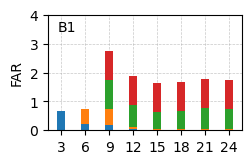

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# 读取Excel文件
file_path = "C:/Users/xmxm/Desktop/汇总制图/汇总NANBNC_b1.xlsx"
sheet_name = "Sheet1"
df = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

# 提取所需数据
data = df.iloc[8:13, 11:19].values

# 将"#DIV/0!"替换为NaN，并转换为浮点数
data[data == "#DIV/0!"] = np.nan
data = data.astype(float)

# 创建堆叠柱状图
rainfall_thresholds = [0.1, 10, 25, 50, 100]
time_intervals = [3, 6, 9, 12, 15, 18, 21, 24]

labels = [str(time) for time in time_intervals]
x = np.arange(len(labels))
bar_width = 0.35

###画布大小
fig, ax = plt.subplots(figsize=(2.5, 1.5))

# 显示网格线并将其设置在底层
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7, zorder=1)

bottom = np.zeros(len(labels))

for i, row in enumerate(data):
    ax.bar(x, row, bar_width, bottom=bottom, label=str(rainfall_thresholds[i]), zorder=2)
    bottom += row

# 提取文件名中的b1作为标题
title = os.path.splitext(os.path.basename(file_path))[0].split('_')[-1].upper()

# 在图内左上角显示标题
plt.text(0.05, 0.95, title, fontsize=10, ha='left', va='top', transform=plt.gca().transAxes)

# 设置标签和标题字体大小
#ax.set_xlabel('Time Intervals', fontsize=10)
ax.set_ylabel('FAR', fontsize=10)
#ax.set_title('Stacked Bar Chart', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)

# 设置图例字体大小并横向排列
#ax.legend(title='Rainfall Thresholds', ncol=5, fontsize=10, title_fontsize=10,shadow=False)

# 设置 y 轴范围
ax.set_ylim(0, 4)  # 你可以根据需要调整范围

# 设置轴刻度标签的字体大小
ax.tick_params(axis='both', which='major', labelsize=10)

plt.show()


In [29]:


###循环输出单图



In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def process_excel_file(file_path, output_folder):
    sheet_name = "Sheet1"
    df = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

    # 提取所需数据
    data = df.iloc[8:13, 11:19].values

    # 将"#DIV/0!"替换为NaN，并转换为浮点数
    data[data == "#DIV/0!"] = np.nan
    data = data.astype(float)

    # 创建堆叠柱状图
    rainfall_thresholds = [0.1, 10, 25, 50, 100]
    time_intervals = [3, 6, 9, 12, 15, 18, 21, 24]

    labels = [str(time) for time in time_intervals]
    x = np.arange(len(labels))
    bar_width = 0.35

    fig, ax = plt.subplots(figsize=(2.5, 1.5))

    # 显示网格线并将其设置在底层
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7, zorder=1)

    bottom = np.zeros(len(labels))

    for i, row in enumerate(data):
        ax.bar(x, row, bar_width, bottom=bottom, label=str(rainfall_thresholds[i]), zorder=2)
        bottom += row

    # 提取文件名中的b1作为标题
    title = os.path.splitext(os.path.basename(file_path))[0].split('_')[-1].upper()

    # 在图内左上角显示标题
    plt.text(0.05, 0.95, title, fontsize=10, ha='left', va='top', transform=plt.gca().transAxes)

    # 设置标签和标题字体大小
    ax.set_ylabel('FAR', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)

    # 设置 y 轴范围
    ax.set_ylim(0, 4)  # 你可以根据需要调整范围

    # 设置轴刻度标签的字体大小
    ax.tick_params(axis='both', which='major', labelsize=10)

    output_file_path = os.path.join(output_folder, f"{os.path.splitext(os.path.basename(file_path))[0]}.tif")
    plt.savefig(output_file_path, dpi=300, bbox_inches='tight')
    plt.close()

# 文件夹路径
folder_path = "C:/Users/xmxm/Desktop/汇总制图"

# 输出文件夹路径
output_folder = "C:/Users/xmxm/Desktop/FAR堆叠"

# 处理文件夹中的所有 Excel 文件
for file_name in os.listdir(folder_path):
    if file_name.endswith('.xlsx'):
        file_path = os.path.join(folder_path, file_name)
        process_excel_file(file_path, output_folder)

        
print("done")

done


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def process_excel_file(file_path, output_folder):
    sheet_name = "Sheet1"
    df = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

    # 提取所需数据
    data = df.iloc[8:13, 11:19].values

    # 将"#DIV/0!"替换为NaN，并转换为浮点数
    data[data == "#DIV/0!"] = np.nan
    data = data.astype(float)

    # 创建堆叠柱状图
    rainfall_thresholds = [0.1, 10, 25, 50, 100]
    time_intervals = [3, 6, 9, 12, 15, 18, 21, 24]

    labels = [str(time) for time in time_intervals]
    x = np.arange(len(labels))
    bar_width = 0.35

    fig, ax = plt.subplots(figsize=(2.5, 1.5))

    # 显示网格线并将其设置在底层
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7, zorder=1)

    bottom = np.zeros(len(labels))

    for i, row in enumerate(data):
        ax.bar(x, row, bar_width, bottom=bottom, label=str(rainfall_thresholds[i]), zorder=2)
        bottom += row

    # 提取文件名中的b1作为标题
    title = os.path.splitext(os.path.basename(file_path))[0].split('_')[-1].upper()

    # 在图内左上角显示标题
    plt.text(0.05, 0.95, title, fontsize=10, ha='left', va='top', transform=plt.gca().transAxes)

    # 设置标签和标题字体大小
    ax.set_ylabel('FAR', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)

    # 设置 y 轴范围
    ax.set_ylim(0, 4)  # 你可以根据需要调整范围

    # 设置轴刻度标签的字体大小
    ax.tick_params(axis='both', which='major', labelsize=10)

    output_file_name = f"{title}.tif"
    output_file_path = os.path.join(output_folder, output_file_name)
    plt.savefig(output_file_path, dpi=300, bbox_inches='tight')
    plt.close()

# 文件夹路径
folder_path = "C:/Users/xmxm/Desktop/汇总制图"

# 输出文件夹路径
output_folder = "C:/Users/xmxm/Desktop/FAR堆叠"

# 处理文件夹中的所有 Excel 文件
for file_name in os.listdir(folder_path):
    if file_name.endswith('.xlsx'):
        file_path = os.path.join(folder_path, file_name)
        process_excel_file(file_path, output_folder)
print("done")

done


In [ ]:

###群图一起输出


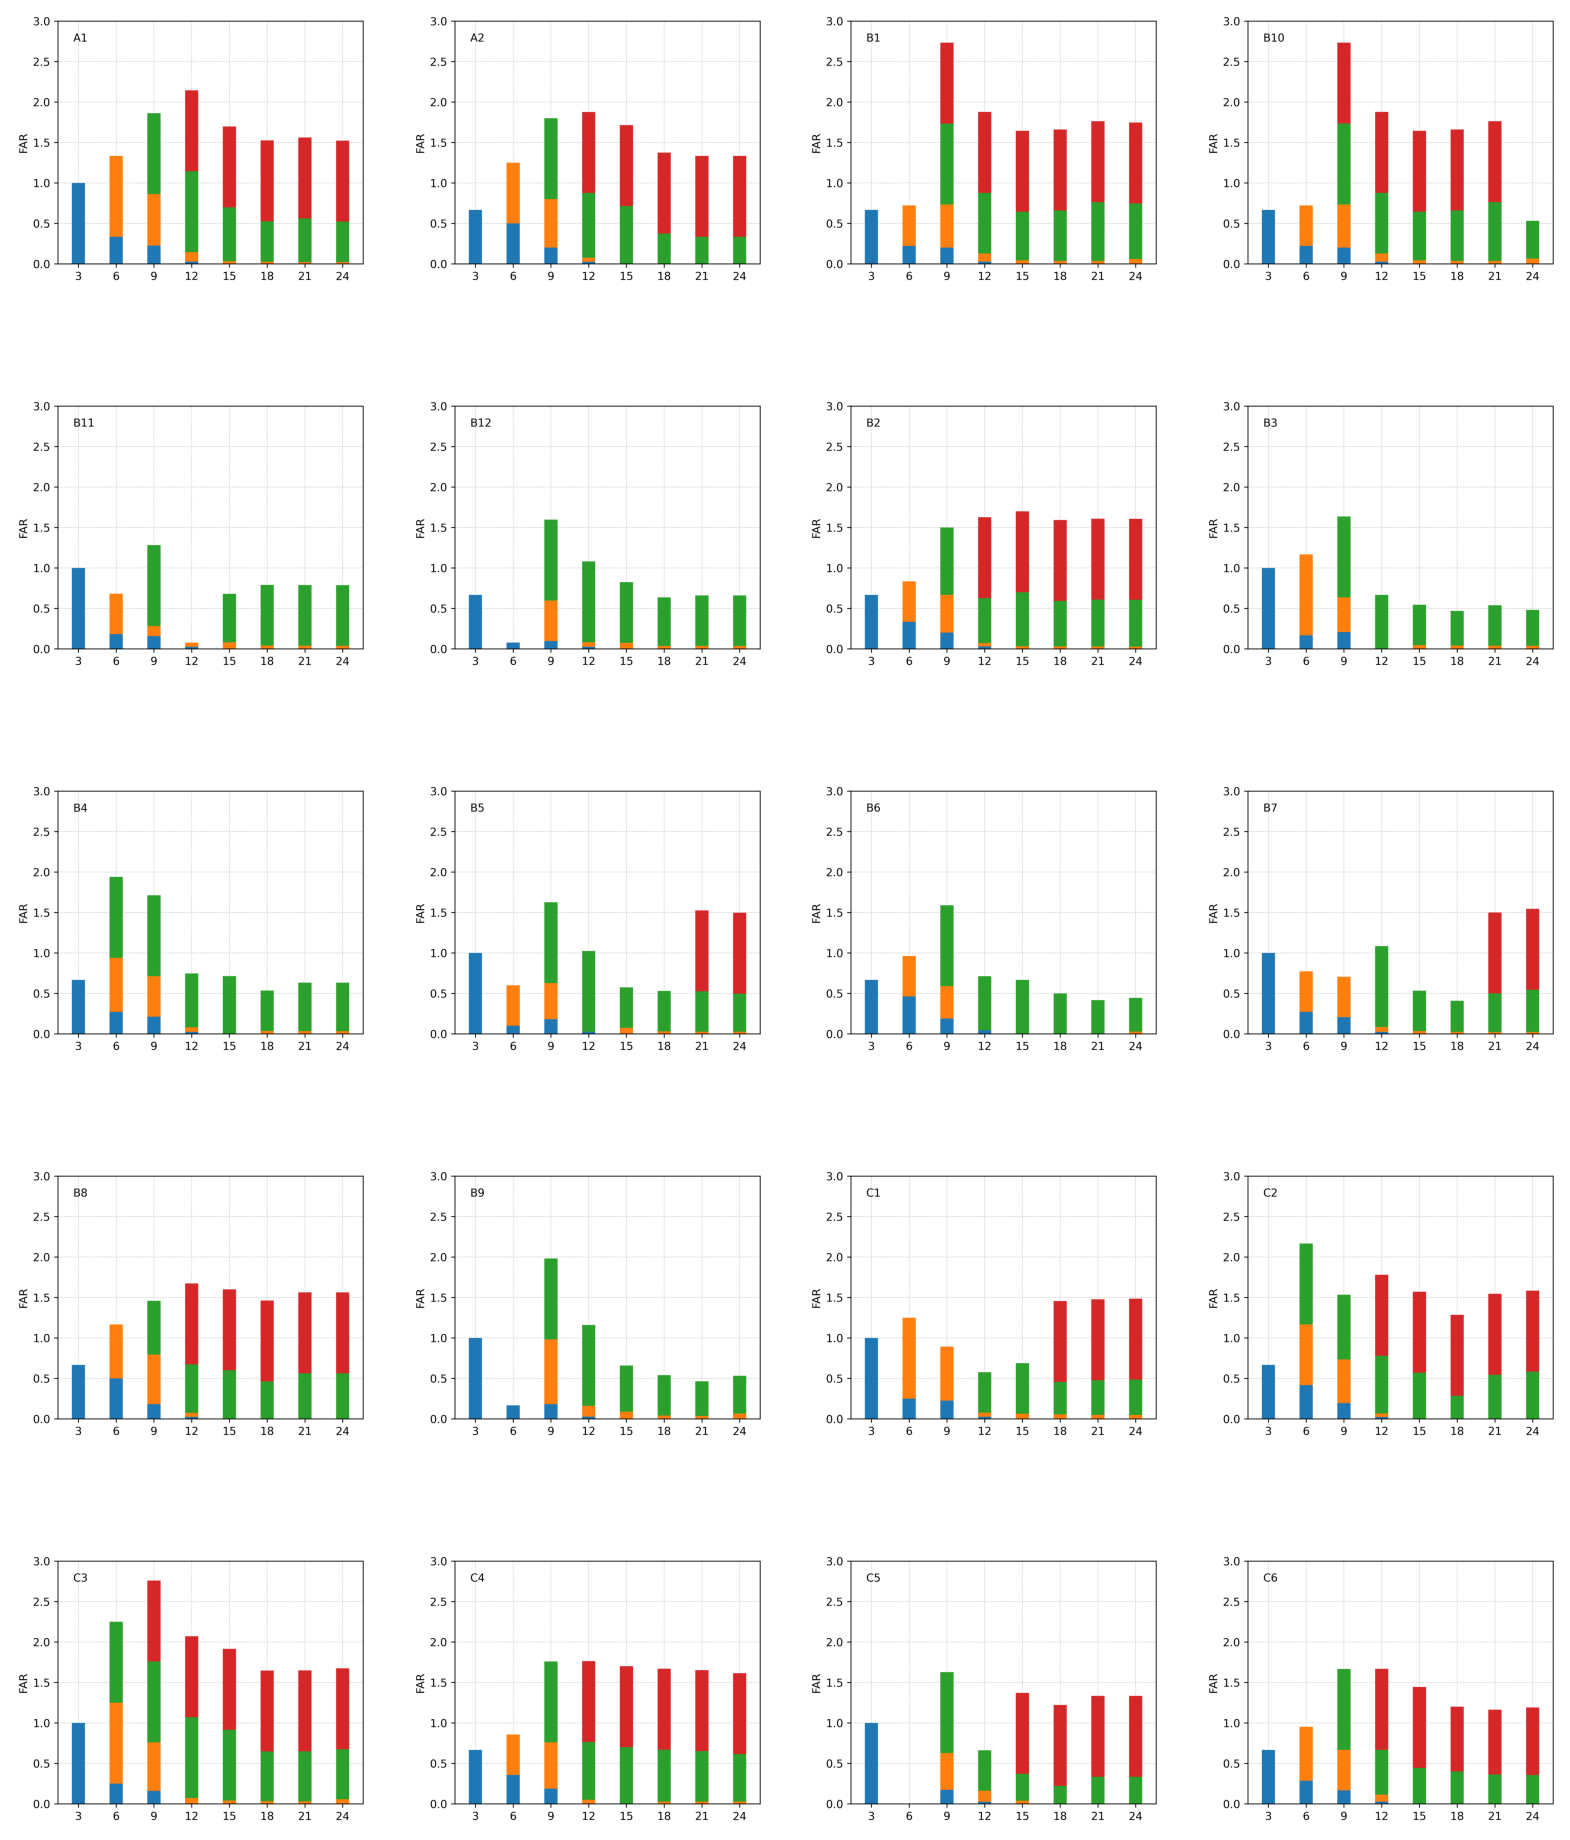

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os


def process_excel_file(file_path, output_folder):
    sheet_name = "Sheet1"
    df = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

    # 提取所需数据
    data = df.iloc[8:13, 11:19].values

    # 将"#DIV/0!"替换为NaN，并转换为浮点数
    data[data == "#DIV/0!"] = np.nan
    data = data.astype(float)

    # 创建堆叠柱状图
    rainfall_thresholds = [0.1, 10, 25, 50, 100]
    time_intervals = [3, 6, 9, 12, 15, 18, 21, 24]

    labels = [str(time) for time in time_intervals]
    x = np.arange(len(labels))
    bar_width = 0.35

    fig, ax = plt.subplots(figsize=(5, 4))

    # 显示网格线并将其设置在底层
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7, zorder=1)

    bottom = np.zeros(len(labels))

    for i, row in enumerate(data):
        ax.bar(x, row, bar_width, bottom=bottom, label=str(rainfall_thresholds[i]), zorder=2)
        bottom += row

    # 提取文件名中的b1作为标题
    title = os.path.splitext(os.path.basename(file_path))[0].split('_')[-1].upper()

    # 在图内左上角显示标题
    plt.text(0.05, 0.95, title, fontsize=10, ha='left', va='top', transform=plt.gca().transAxes)

    # 设置标签和标题字体大小
    ax.set_ylabel('FAR', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)

    # 设置 y 轴范围
    ax.set_ylim(0, 3)  # 你可以根据需要调整范围

    # 设置轴刻度标签的字体大小
    ax.tick_params(axis='both', which='major', labelsize=10)

    output_file_name = f"{title}.tif"
    output_file_path = os.path.join(output_folder, output_file_name)
    plt.savefig(output_file_path, dpi=600, bbox_inches='tight')
    plt.close()

# 文件夹路径
folder_path = "C:/Users/xmxm/Desktop/汇总制图"

# 输出文件夹路径
output_folder = "C:/Users/xmxm/Desktop/FAR堆叠"

# 处理文件夹中的所有 Excel 文件
files = [file_name for file_name in os.listdir(folder_path) if file_name.endswith('.xlsx')]
num_files = len(files)

fig, axes = plt.subplots(5, 4, figsize=(20, 25))
axes = axes.flatten()

for idx, file_name in enumerate(files):
    file_path = os.path.join(folder_path, file_name)
    process_excel_file(file_path, output_folder)
    output_file_name = os.path.splitext(file_name)[0].split('_')[-1].upper()
    output_file_path = os.path.join(output_folder, f"{output_file_name}.tif")
    img = plt.imread(output_file_path)
    axes[idx].imshow(img)
    axes[idx].axis('off')

plt.subplots_adjust(wspace=0.1, hspace=0.001)
plt.savefig(os.path.join(output_folder, "combined_images.tif"), dpi=600, bbox_inches='tight')
plt.show()


In [ ]:
##调整出图顺序
##调整出图顺序
##调整出图顺序

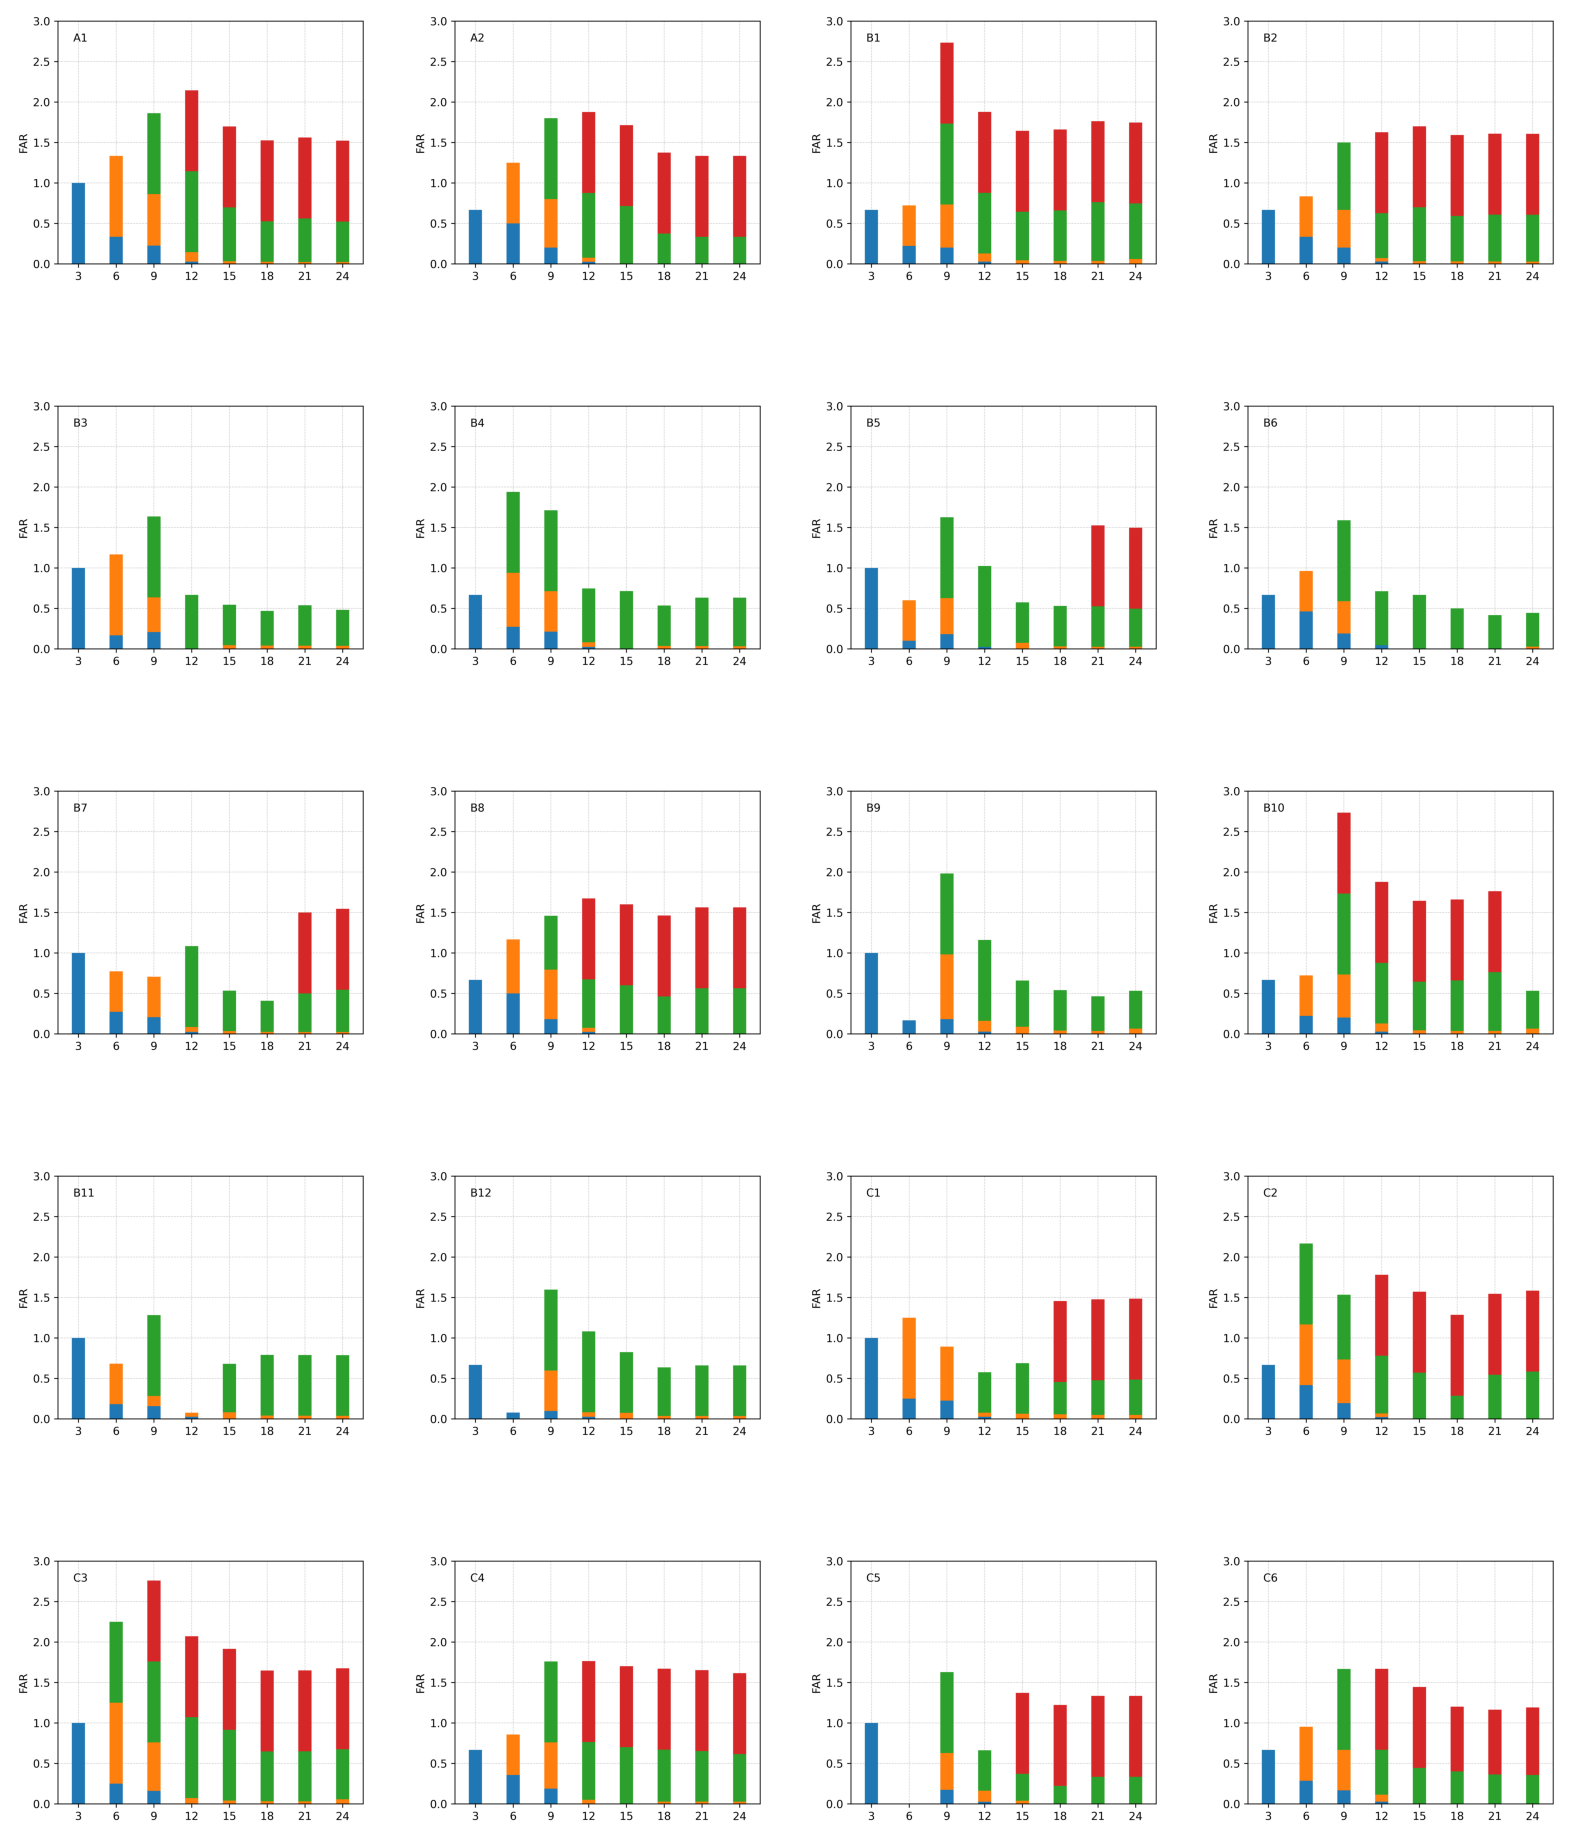

In [3]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re


def natural_sort_key(s, _nsre=re.compile('([0-9]+)')):
    return [int(text) if text.isdigit() else text.lower() for text in _nsre.split(s)]


def process_excel_file(file_path, output_folder):
    sheet_name = "Sheet1"
    df = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

    # 提取所需数据
    data = df.iloc[8:13, 11:19].values

    # 将"#DIV/0!"替换为NaN，并转换为浮点数
    data[data == "#DIV/0!"] = np.nan
    data = data.astype(float)

    # 创建堆叠柱状图
    rainfall_thresholds = [0.1, 10, 25, 50, 100]
    time_intervals = [3, 6, 9, 12, 15, 18, 21, 24]

    labels = [str(time) for time in time_intervals]
    x = np.arange(len(labels))
    bar_width = 0.35

    fig, ax = plt.subplots(figsize=(5, 4))

    # 显示网格线并将其设置在底层
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7, zorder=1)

    bottom = np.zeros(len(labels))

    for i, row in enumerate(data):
        ax.bar(x, row, bar_width, bottom=bottom, label=str(rainfall_thresholds[i]), zorder=2)
        bottom += row

    # 提取文件名中的b1作为标题
    title = os.path.splitext(os.path.basename(file_path))[0].split('_')[-1].upper()

    # 在图内左上角显示标题
    plt.text(0.05, 0.95, title, fontsize=10, ha='left', va='top', transform=plt.gca().transAxes)

    # 设置标签和标题字体大小
    ax.set_ylabel('FAR', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)

    # 设置 y 轴范围
    ax.set_ylim(0, 3)  # 你可以根据需要调整范围

    # 设置轴刻度标签的字体大小
    ax.tick_params(axis='both', which='major', labelsize=10)

    output_file_name = f"{title}.tif"
    output_file_path = os.path.join(output_folder, output_file_name)
    plt.savefig(output_file_path, dpi=600, bbox_inches='tight')
    plt.close()


# 文件夹路径
folder_path = "C:/Users/xmxm/Desktop/汇总制图"

# 输出文件夹路径
output_folder = "C:/Users/xmxm/Desktop/FAR堆叠"
os.makedirs(output_folder, exist_ok=True)

# 处理文件夹中的所有 Excel 文件
files = [file_name for file_name in os.listdir(folder_path) if file_name.endswith('.xlsx')]
files.sort(key=natural_sort_key)
num_files = len(files)

fig, axes = plt.subplots(5, 4, figsize=(20, 25))
axes = axes.flatten()

for idx, file_name in enumerate(files):
    file_path = os.path.join(folder_path, file_name)
    process_excel_file(file_path, output_folder)
    output_file_name = os.path.splitext(file_name)[0].split('_')[-1].upper()
    output_file_path = os.path.join(output_folder, f"{output_file_name}.tif")
    img = plt.imread(output_file_path)
    axes[idx].imshow(img)
    axes[idx].axis('off')

plt.subplots_adjust(wspace=0.1, hspace=0.001)
plt.savefig(os.path.join(output_folder, "combined_images.tif"), dpi=600, bbox_inches='tight')
plt.show()


In [ ]:
###调整字体大小
###调整字体大小
###调整字体大小

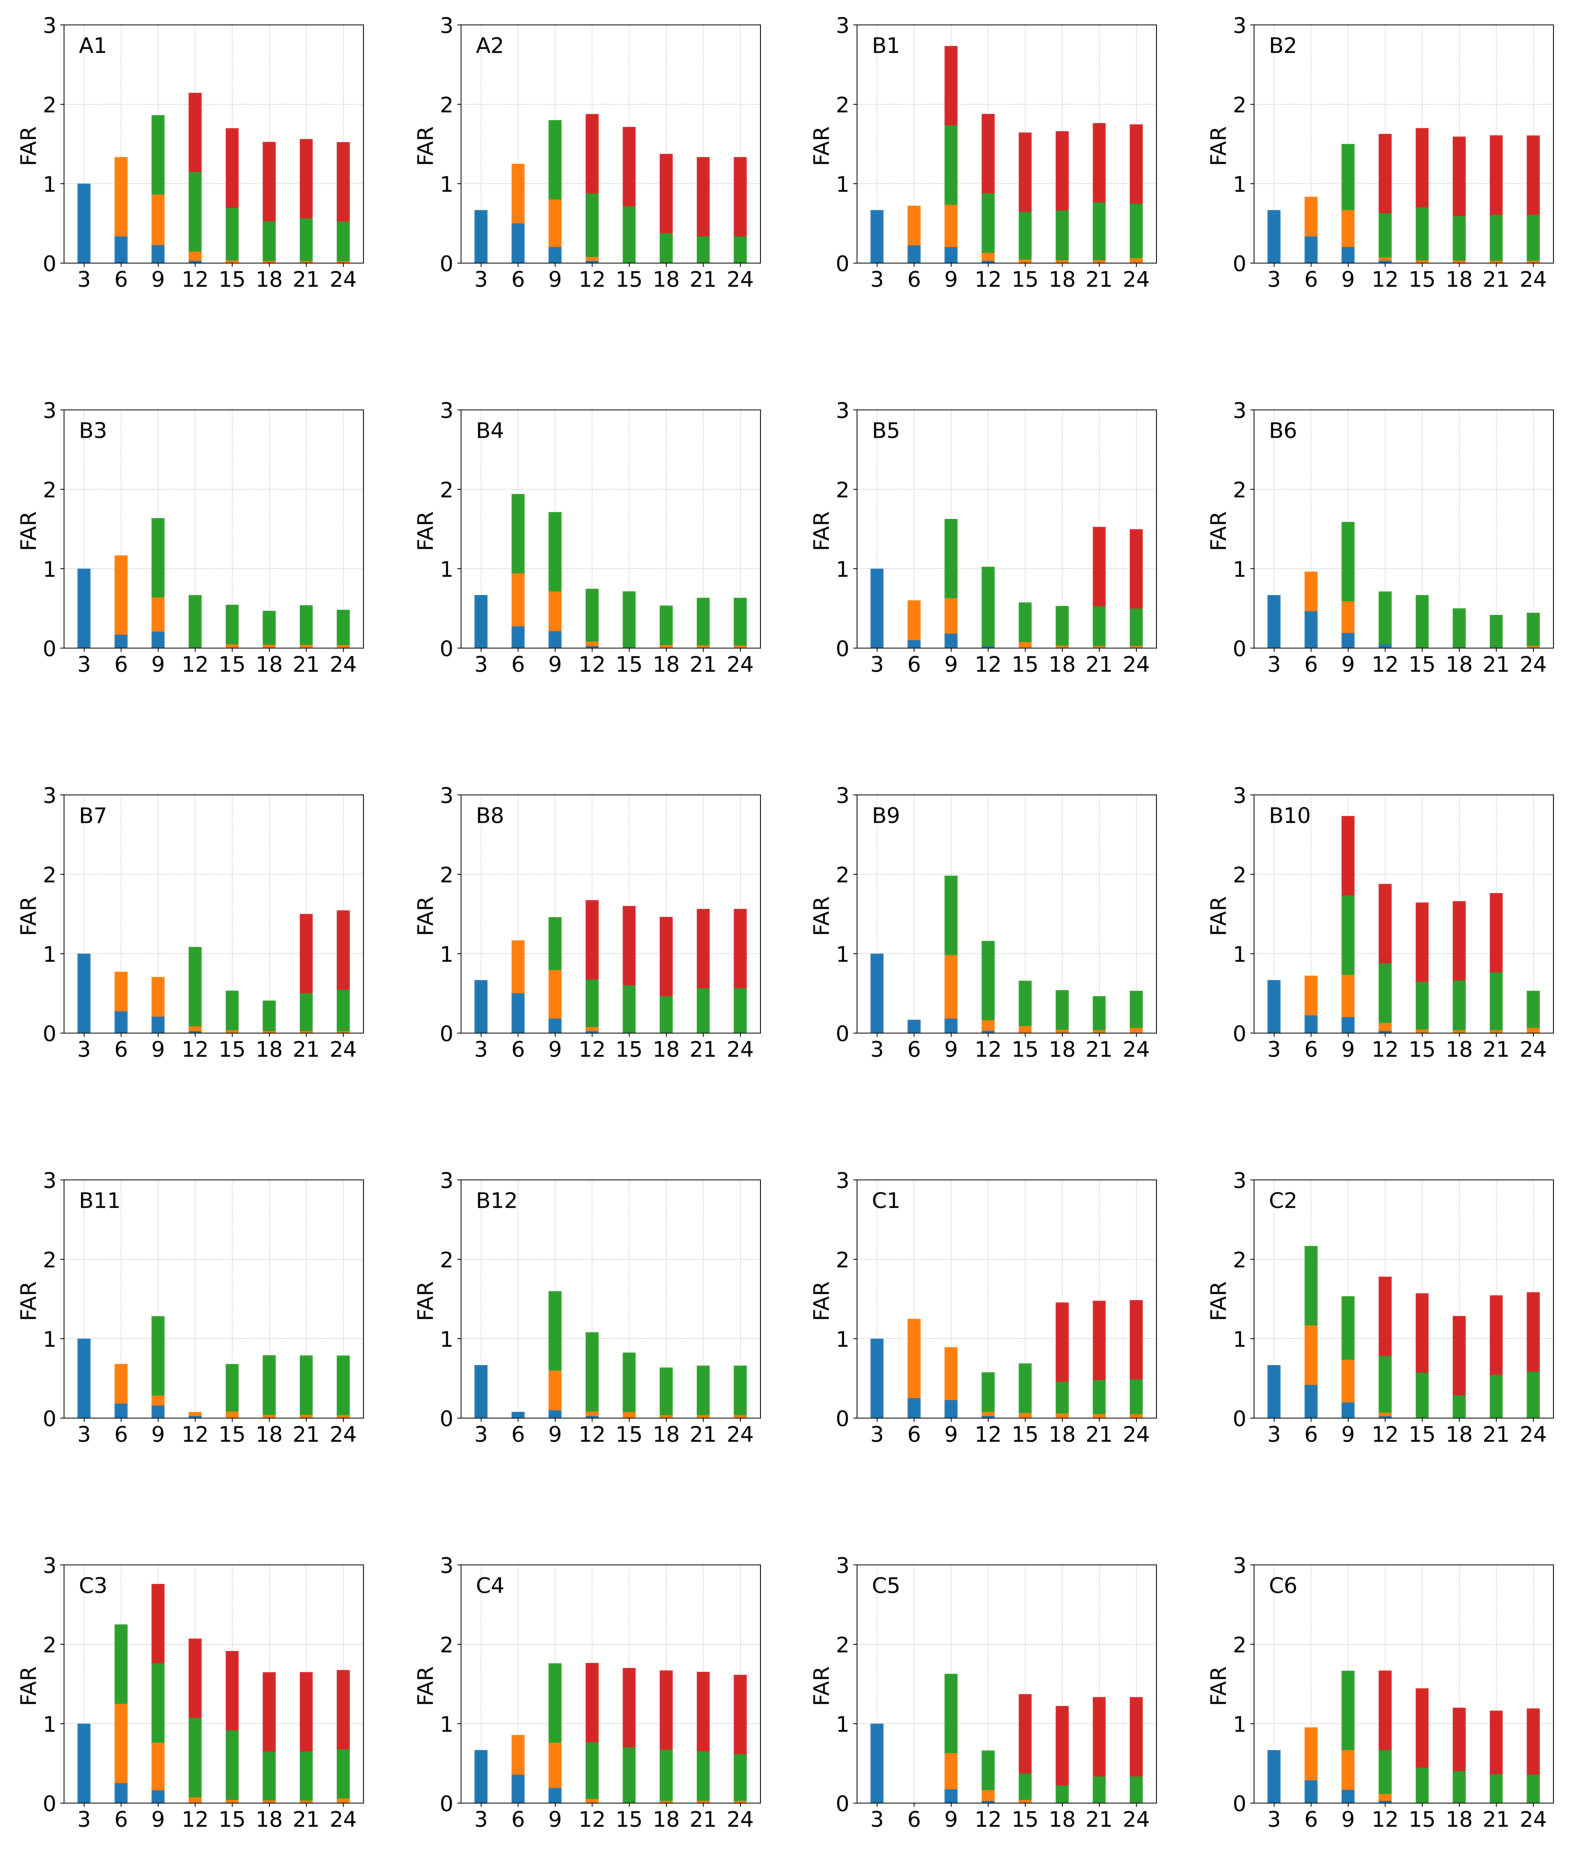

In [4]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re


def natural_sort_key(s, _nsre=re.compile('([0-9]+)')):
    return [int(text) if text.isdigit() else text.lower() for text in _nsre.split(s)]


def process_excel_file(file_path, output_folder):
    sheet_name = "Sheet1"
    df = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

    # 提取所需数据
    data = df.iloc[8:13, 11:19].values

    # 将"#DIV/0!"替换为NaN，并转换为浮点数
    data[data == "#DIV/0!"] = np.nan
    data = data.astype(float)

    # 创建堆叠柱状图
    rainfall_thresholds = [0.1, 20, 25, 50, 200]
    time_intervals = [3, 6, 9, 12, 15, 18, 21, 24]

    labels = [str(time) for time in time_intervals]
    x = np.arange(len(labels))
    bar_width = 0.35

    fig, ax = plt.subplots(figsize=(5, 4))

    # 显示网格线并将其设置在底层
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7, zorder=1)

    bottom = np.zeros(len(labels))

    for i, row in enumerate(data):
        ax.bar(x, row, bar_width, bottom=bottom, label=str(rainfall_thresholds[i]), zorder=2)
        bottom += row

    # 提取文件名中的b1作为标题
    title = os.path.splitext(os.path.basename(file_path))[0].split('_')[-1].upper()

    # 在图内左上角显示标题
    plt.text(0.05, 0.95, title, fontsize=20, ha='left', va='top', transform=plt.gca().transAxes)

    # 设置标签和标题字体大小
    ax.set_ylabel('FAR', fontsize=20)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=20)

    # 设置 y 轴范围
    ax.set_ylim(0, 3)  # 你可以根据需要调整范围

    # 设置轴刻度标签的字体大小
    ax.tick_params(axis='both', which='major', labelsize=20)

    output_file_name = f"{title}.tif"
    output_file_path = os.path.join(output_folder, output_file_name)
    plt.savefig(output_file_path, dpi=600, bbox_inches='tight')
    plt.close()


# 文件夹路径
folder_path = "C:/Users/xmxm/Desktop/汇总制图"

# 输出文件夹路径
output_folder = "C:/Users/xmxm/Desktop/FAR堆叠"
os.makedirs(output_folder, exist_ok=True)

# 处理文件夹中的所有 Excel 文件
files = [file_name for file_name in os.listdir(folder_path) if file_name.endswith('.xlsx')]
files.sort(key=natural_sort_key)
num_files = len(files)

fig, axes = plt.subplots(5, 4, figsize=(20, 25))
axes = axes.flatten()

for idx, file_name in enumerate(files):
    file_path = os.path.join(folder_path, file_name)
    process_excel_file(file_path, output_folder)
    output_file_name = os.path.splitext(file_name)[0].split('_')[-1].upper()
    output_file_path = os.path.join(output_folder, f"{output_file_name}.tif")
    img = plt.imread(output_file_path)
    axes[idx].imshow(img)
    axes[idx].axis('off')

plt.subplots_adjust(wspace=0.1, hspace=0.001)
plt.savefig(os.path.join(output_folder, "combined_images.tif"), dpi=600, bbox_inches='tight')
plt.show()


In [ ]:
###左侧加text
###左侧加text
###左侧加text

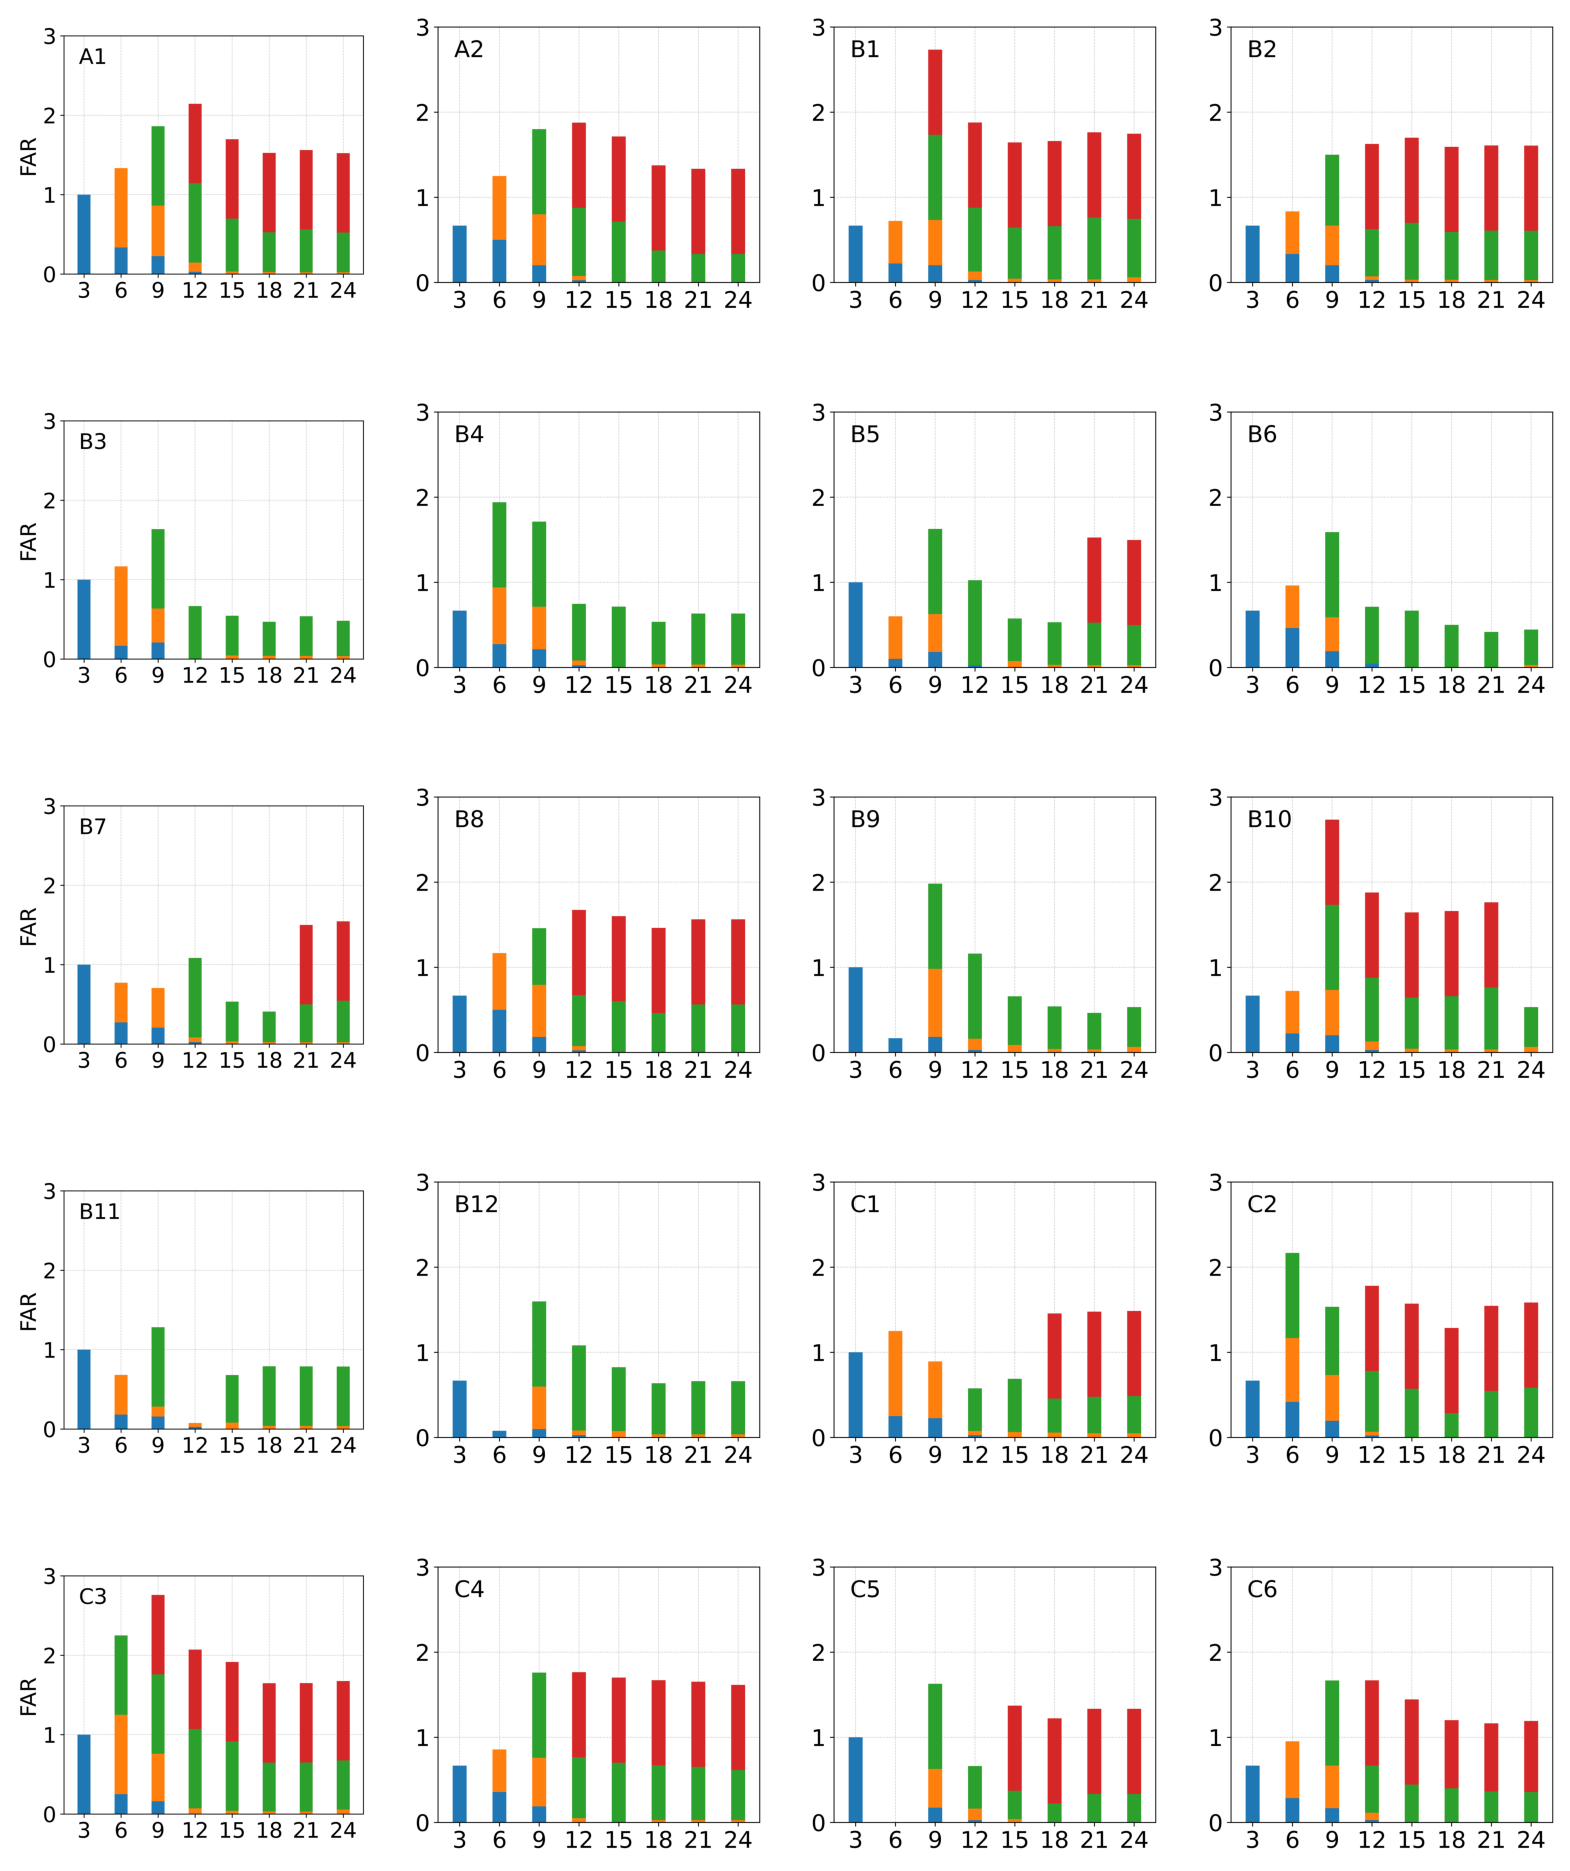

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re

def natural_sort_key(s, _nsre=re.compile('([0-9]+)')):
    return [int(text) if text.isdigit() else text.lower() for text in _nsre.split(s)]


###最左侧 加text
def process_excel_file(file_path, output_folder, show_ylabel=False):
    sheet_name = "Sheet1"
    df = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

    # 提取所需数据
    data = df.iloc[8:13, 11:19].values

    # 将"#DIV/0!"替换为NaN，并转换为浮点数
    data[data == "#DIV/0!"] = np.nan
    data = data.astype(float)

    # 创建堆叠柱状图
    rainfall_thresholds = [0.1, 20, 25, 50, 200]
    time_intervals = [3, 6, 9, 12, 15, 18, 21, 24]

    labels = [str(time) for time in time_intervals]
    x = np.arange(len(labels))
    bar_width = 0.35

    fig, ax = plt.subplots(figsize=(5, 4))

    # 显示网格线并将其设置在底层
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7, zorder=1)

    bottom = np.zeros(len(labels))

    for i, row in enumerate(data):
        ax.bar(x, row, bar_width, bottom=bottom, label=str(rainfall_thresholds[i]), zorder=2)
        bottom += row

    # 提取文件名中的b1作为标题
    title = os.path.splitext(os.path.basename(file_path))[0].split('_')[-1].upper()

    # 在图内左上角显示标题
    plt.text(0.05, 0.95, title, fontsize=20, ha='left', va='top', transform=plt.gca().transAxes)

    # 设置标签和标题字体大小
    if show_ylabel:
        ax.set_ylabel('FAR', fontsize=20)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=20)

    # 设置 y 轴范围
    ax.set_ylim(0, 3)  # 你可以根据需要调整范围

    # 设置轴刻度标签的字体大小
    ax.tick_params(axis='both', which='major', labelsize=20)

    output_file_name = f"{title}.tif"
    output_file_path = os.path.join(output_folder, output_file_name)
    plt.savefig(output_file_path, dpi=600, bbox_inches='tight')
    plt.close()

# 文件夹路径
folder_path = "C:/Users/xmxm/Desktop/汇总制图"

# 输出文件夹路径
output_folder = "C:/Users/xmxm/Desktop/FAR堆叠"
os.makedirs(output_folder, exist_ok=True)

# 处理文件夹中的所有 Excel 文件
files = [file_name for file_name in os.listdir(folder_path) if file_name.endswith('.xlsx')]
files.sort(key=natural_sort_key)
num_files = len(files)

fig, axes = plt.subplots(5, 4, figsize=(20, 25))
axes = axes.flatten()

for idx, file_name in enumerate(files):
    file_path = os.path.join(folder_path, file_name)
    show_ylabel = (idx % 4 == 0)
    process_excel_file(file_path, output_folder, show_ylabel=show_ylabel)
    output_file_name = os.path.splitext(file_name)[0].split('_')[-1].upper()
    output_file_path = os.path.join(output_folder, f"{output_file_name}.tif")
    img = plt.imread(output_file_path)
    axes[idx].imshow(img)
    axes[idx].axis('off')

plt.subplots_adjust(wspace=0.1, hspace=0.001)
plt.savefig(os.path.join(output_folder, "combined_images.tif"), dpi=600, bbox_inches='tight')
plt.show()


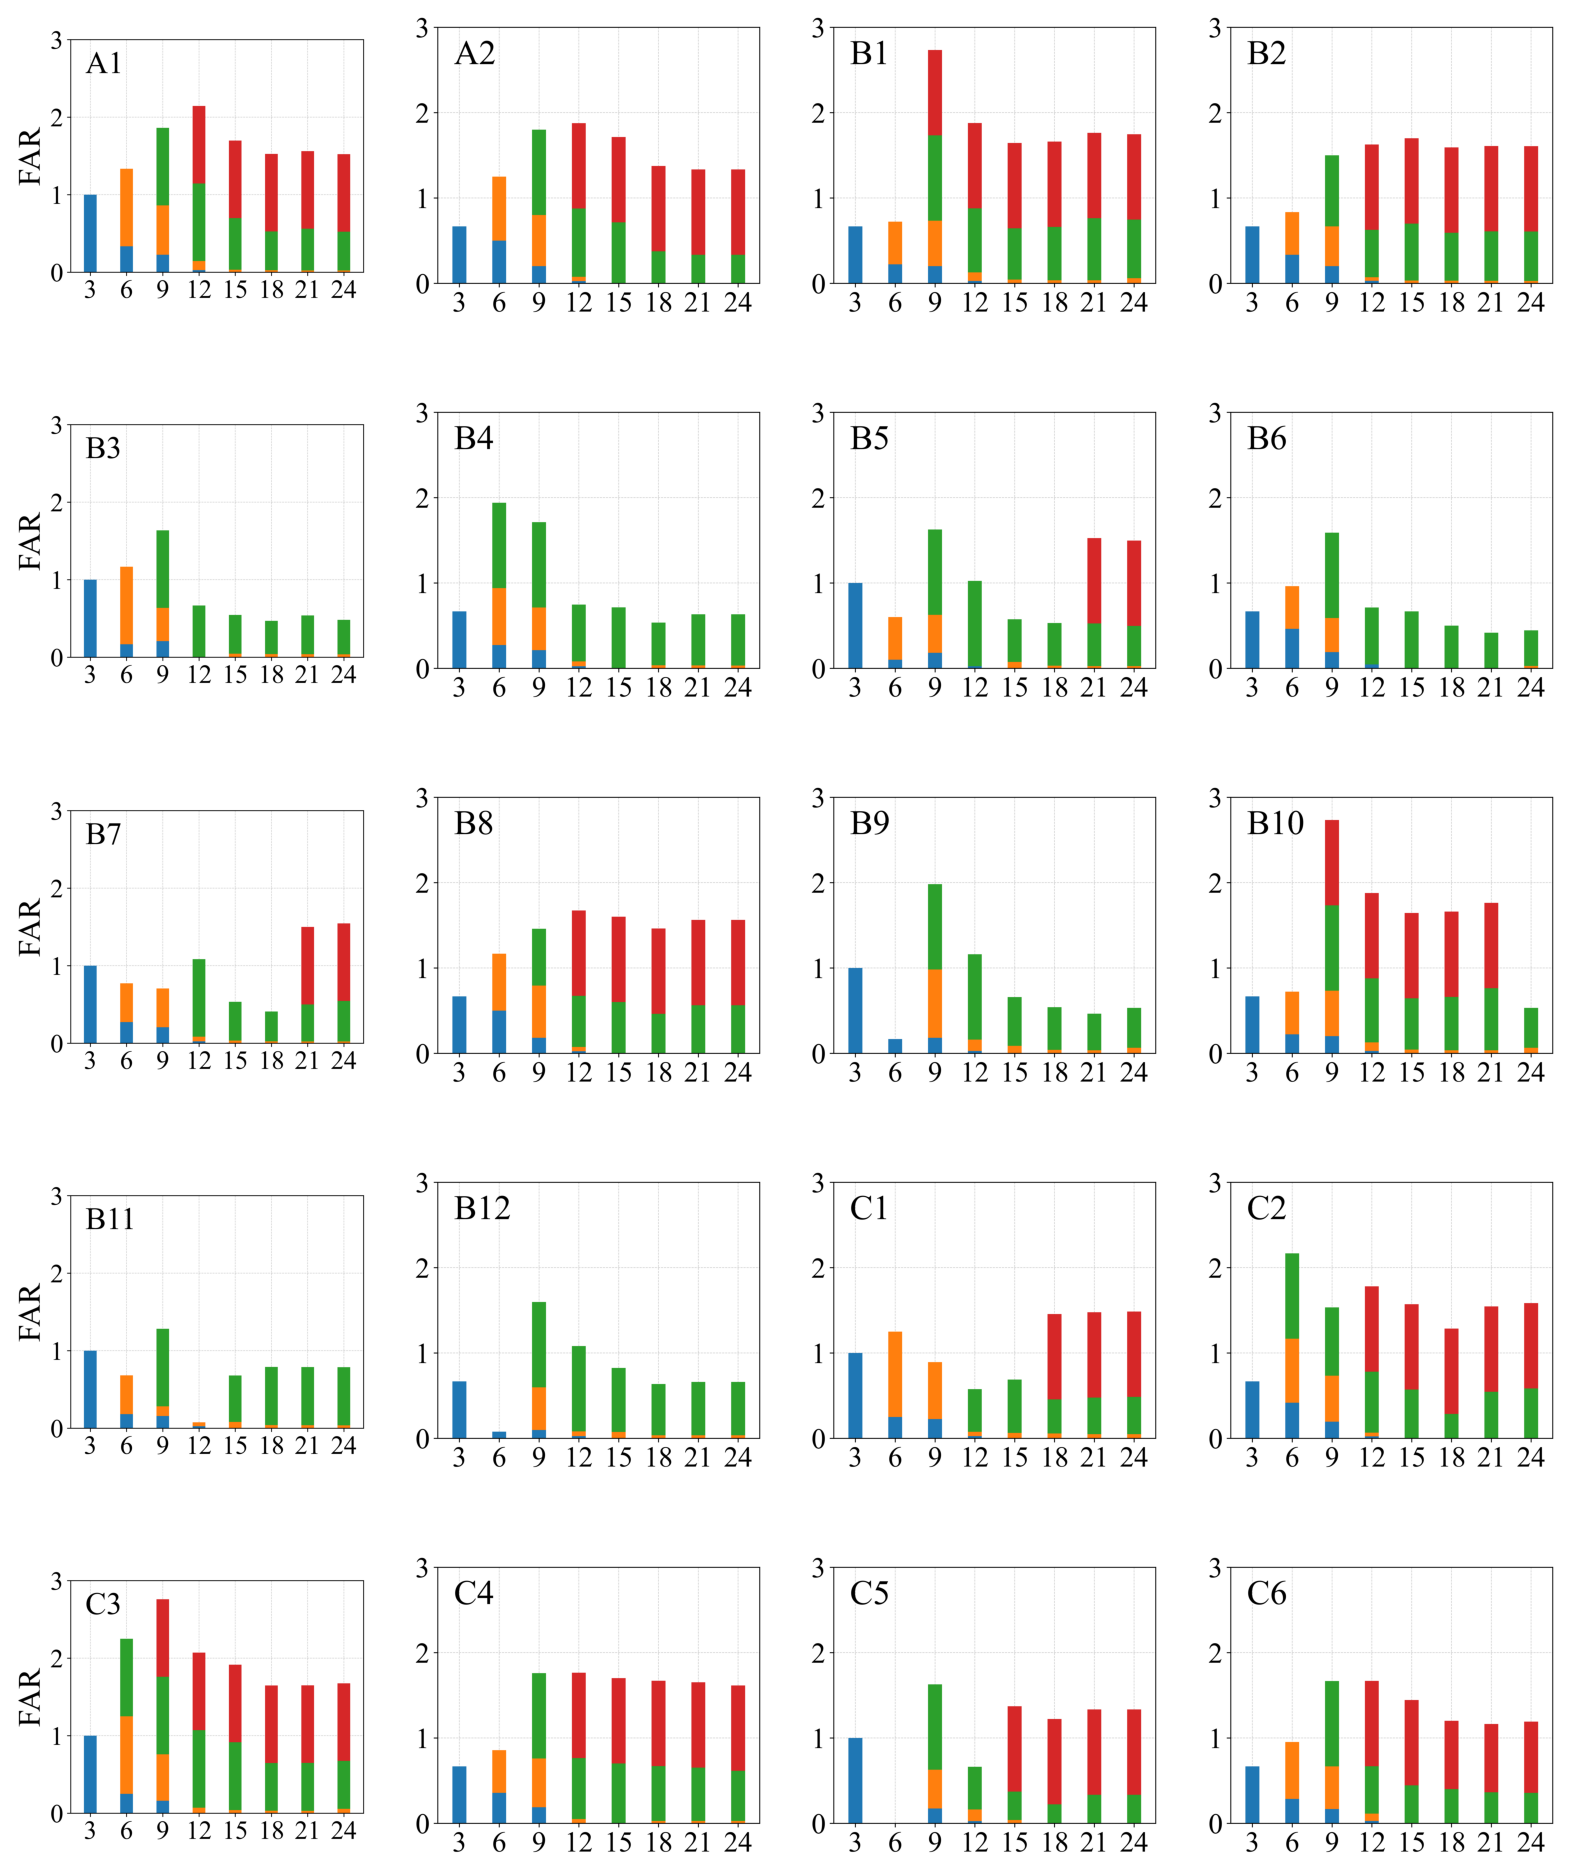

In [6]:
###修改字体
###修改字体
###修改字体

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re

def natural_sort_key(s, _nsre=re.compile('([0-9]+)')):
    return [int(text) if text.isdigit() else text.lower() for text in _nsre.split(s)]
'''
# 设置全局字体大小
y=25     #字号
plt.rcParams.update({
    'font.size'      : y,
    'axes.titlesize' : y,
    'axes.labelsize' : y,
    'xtick.labelsize': y,
    'ytick.labelsize': y,
    'font.family':'Times New Roman'
})
'''
# 设置全局字体大小

plt.rcParams.update({ 'font.family':'Times New Roman'
})
###最左侧 加text
def process_excel_file(file_path, output_folder, show_ylabel=False):
    sheet_name = "Sheet1"
    df = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

    # 提取所需数据
    data = df.iloc[8:13, 11:19].values

    # 将"#DIV/0!"替换为NaN，并转换为浮点数
    data[data == "#DIV/0!"] = np.nan
    data = data.astype(float)

    # 创建堆叠柱状图
    rainfall_thresholds = [0.1, 20, 25, 50, 200]
    time_intervals = [3, 6, 9, 12, 15, 18, 21, 24]

    labels = [str(time) for time in time_intervals]
    x = np.arange(len(labels))
    bar_width = 0.35

    fig, ax = plt.subplots(figsize=(5, 4))

    # 显示网格线并将其设置在底层
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7, zorder=1)

    bottom = np.zeros(len(labels))

    for i, row in enumerate(data):
        ax.bar(x, row, bar_width, bottom=bottom, label=str(rainfall_thresholds[i]), zorder=2)
        bottom += row

    # 提取文件名中的b1作为标题
    title = os.path.splitext(os.path.basename(file_path))[0].split('_')[-1].upper()

    # 在图内左上角显示标题
    plt.text(0.05, 0.95, title, fontsize=30, ha='left', va='top', transform=plt.gca().transAxes)

    # 设置标签和标题字体大小
    if show_ylabel:
        ax.set_ylabel('FAR', fontsize=30)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=30)

    # 设置 y 轴范围
    ax.set_ylim(0, 3)  # 你可以根据需要调整范围

    # 设置轴刻度标签的字体大小
    ax.tick_params(axis='both', which='major', labelsize=25)

    output_file_name = f"{title}.tif"
    output_file_path = os.path.join(output_folder, output_file_name)
    plt.savefig(output_file_path, dpi=600, bbox_inches='tight')
    plt.close()

# 文件夹路径
folder_path = "C:/Users/xmxm/Desktop/汇总制图"

# 输出文件夹路径
output_folder = "C:/Users/xmxm/Desktop/FAR堆叠"
os.makedirs(output_folder, exist_ok=True)

# 处理文件夹中的所有 Excel 文件
files = [file_name for file_name in os.listdir(folder_path) if file_name.endswith('.xlsx')]
files.sort(key=natural_sort_key)
num_files = len(files)

fig, axes = plt.subplots(5, 4, figsize=(20, 25))
axes = axes.flatten()

for idx, file_name in enumerate(files):
    file_path = os.path.join(folder_path, file_name)
    show_ylabel = (idx % 4 == 0)
    process_excel_file(file_path, output_folder, show_ylabel=show_ylabel)
    output_file_name = os.path.splitext(file_name)[0].split('_')[-1].upper()
    output_file_path = os.path.join(output_folder, f"{output_file_name}.tif")
    img = plt.imread(output_file_path)
    axes[idx].imshow(img)
    axes[idx].axis('off')


plt.subplots_adjust(wspace=0.1, hspace=0.001)
plt.savefig(os.path.join(output_folder, "combined_images30.tif"), dpi=600, bbox_inches='tight')
plt.show()
